# LSTM con serie de tiepo total visitantes internacionales

## 1. Carga de los datos y construcción de la serie

In [39]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (13, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

RAIZ = Path.cwd().resolve()
while not (RAIZ / "data").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

RUTA_DATOS = RAIZ / "data" / "raw" / "Base_Migracion_2009-2026jun.xlsx"
assert RUTA_DATOS.exists(), f"No se encontro {RUTA_DATOS}"

datos_raw = pd.read_excel(RUTA_DATOS, sheet_name="Datos")

datos = datos_raw.copy()
datos["Fecha"] = pd.to_datetime(
    dict(year=datos["Año"], month=datos["Mes cod"], day=1),
    errors="coerce"
)
datos = datos.sort_values("Fecha").reset_index(drop=True)

# Calendario completo de meses: asegura frecuencia mensual regular al reindexar.
meses_esperados = pd.date_range(
    datos["Fecha"].min(), datos["Fecha"].max(), freq="MS"
)

print(f"Registros:      {len(datos):,}")
print(f"Periodo:        {datos['Fecha'].min():%Y-%m} a {datos['Fecha'].max():%Y-%m} "
      f"({len(meses_esperados)} meses)")
print(f"Meses ausentes: {len(meses_esperados.difference(datos['Fecha'].unique()))}")
print(f"Fechas nulas:   {datos['Fecha'].isna().sum()}")
display(datos.head(3))

Registros:      161,036
Periodo:        2009-01 a 2026-06 (210 meses)
Meses ausentes: 0
Fechas nulas:   0


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.00,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.00,2009-01-01


> Con esto cargamos todos los datos a nuestro data set, para ver el total internacional de visitantes a guatemala, tenemos registros desde el 1ero de Enero del 2009 hasta Junio del 2026. Exactamente son 210 meses de datos en donde no tenemos meses
> faltantes ni fechas nulas.

### 1.2 Criterio de comparabilidad: filtros aplicados

Se aplican **dos** filtros, ambos por comparabilidad temporal y no por criterio
conceptual. La fuente cambia de metodología en 2023 y sin estos filtros la serie
mezclaría universos distintos:

1. **`Tipo de Viajero` ∈ {Turista, Excursionista}.** Se excluyen `Cruceristas`
   (deja de reportarse desde 2023) y `Viajero` (se reclasifica y pierde ~70% de
   nivel en 2023). Ninguno de los dos quiebres corresponde a un cambio real del
   turismo.
2. **`País` ≠ `Guatemala`.** La etiqueta `Guatemala` (residentes que reingresan al
   país) representa entre 34% y 48% del total hasta 2022 y **desaparece por
   completo desde enero de 2023**, sin ser reabsorbida por ninguna otra agrupación.
   Mantenerla introduciría un quiebre de nivel dentro del conjunto de prueba.

La evidencia de ambos quiebres se documenta en la celda siguiente.

In [40]:
# ---------------------------------------------------------------------------
# Quiebre 1: la columna "Tipo de Viajero"
# ---------------------------------------------------------------------------
quiebre_tipo = datos.pivot_table(
    index="Año", columns="Tipo de Viajero", values="Viajero",
    aggfunc="sum", fill_value=0
)

print("Quiebre 1 — totales anuales por Tipo de Viajero")
display(quiebre_tipo.loc[2019:])

# ---------------------------------------------------------------------------
# Quiebre 2: la etiqueta "Guatemala" dentro de la columna "País"
# Se evalúa ya con el filtro de tipo aplicado, que es el universo relevante.
# ---------------------------------------------------------------------------
visitantes_todo_pais = datos.loc[
    datos["Tipo de Viajero"].isin(["Turista", "Excursionista"])
]

total_anual = visitantes_todo_pais.groupby("Año")["Viajero"].sum()
gt_anual = (
    visitantes_todo_pais.loc[visitantes_todo_pais["País"] == "Guatemala"]
                        .groupby("Año")["Viajero"]
                        .sum()
                        .reindex(total_anual.index, fill_value=0)
)

quiebre_pais = pd.DataFrame({
    "Total (Turista + Excursionista)": total_anual,
    "Etiqueta 'Guatemala'": gt_anual,
    "% del total": 100 * gt_anual / total_anual
})

print("\nQuiebre 2 — peso anual de la etiqueta 'Guatemala'")
display(quiebre_pais)

etiquetas_2023 = sorted(
    visitantes_todo_pais.loc[visitantes_todo_pais["Año"] >= 2023, "País"].unique()
)
print(f"\nEtiquetas de 'País' presentes desde 2023 ({len(etiquetas_2023)}):")
print(", ".join(etiquetas_2023))
print(f"\n¿'Guatemala' aparece desde 2023?: {'Guatemala' in etiquetas_2023}")

Quiebre 1 — totales anuales por Tipo de Viajero


Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Año,,,,
2019,"130,789.00","1,081,250.85","3,050,999.75","428,780.60"
2020,"41,992.00","262,573.14","797,197.29","164,577.71"
2021,"3,908.00","82,470.05","1,016,494.33","164,895.39"
2022,"26,030.00","550,371.00","2,678,957.60","1,060,805.80"
2023,0.00,"793,847.06","2,123,979.75","330,882.19"
2024,0.00,"833,527.49","2,440,908.51","319,440.00"
2025,0.00,"811,391.52","2,540,897.14","244,949.34"
2026,0.00,"345,939.38","1,230,680.10","106,016.52"



Quiebre 2 — peso anual de la etiqueta 'Guatemala'


,Total (Turista + Excursionista),Etiqueta 'Guatemala',% del total
Año,,,
2009,"1,880,182.85","650,682.75",34.61
2010,"2,004,784.00","693,639.38",34.60
2011,"2,079,714.60","717,712.45",34.51
2012,"2,139,541.48","721,106.49",33.70
2013,"2,289,702.75","845,736.86",36.94
2014,"2,660,177.32","991,887.70",37.29
2015,"2,917,886.04","1,129,942.29",38.72
2016,"2,997,026.74","1,194,555.66",39.86
2017,"3,307,651.29","1,323,495.14",40.01



Etiquetas de 'País' presentes desde 2023 (26):
Alemania, Argentina, Australia, Belice, Brasil, Canadá, China, Colombia, Costa Rica, El Salvador, España, Estados Unidos de América, Federación de Rusia, Francia, Honduras, Israel, Italia, Japón, México, Nicaragua, Otros Países de América del Sur, Otros Países de Europa, Panamá, Países Bajos, Reino Unido de Gran Bretaña e Irlanda del Norte, Resto del Mundo

¿'Guatemala' aparece desde 2023?: False


> Tuvimos que hacer unos quiebres en los datos para que nuestra serie quedara de la manera que nosotros queriamos. Primero lo que hicimos fue excluir los tipos Viajero y Crucerita
> Esto porque el tipo Crucerista deja de registrarse a partir de 2023 y el tipo Viajero decae mucho igualmente apartir de esta fecha
> 
> Luego excluimos la etiqueta de Guatemala dado que se deja de registrar desde 2023 y para viajeros internacionales no tiene mucho sentido incluir a los nacionales


### 1.3 Construcción de la serie total mensual

Se agrega por mes y se reindexa sobre los 210 meses del calendario para garantizar
frecuencia mensual regular (`MS`), requisito de la descomposición, las pruebas de
raíz unitaria y el modelado.

Filas usadas:   132,894 de 161,036
Observaciones:  210  |  NaN: 0  |  freq: <MonthBegin>
Acumulado:      32,841,522


,Visitantes
count,210.00
mean,"156,388.20"
std,"74,176.33"
min,0.00
25%,"110,282.64"
50%,"146,394.81"
75%,"205,989.87"
max,"365,573.02"


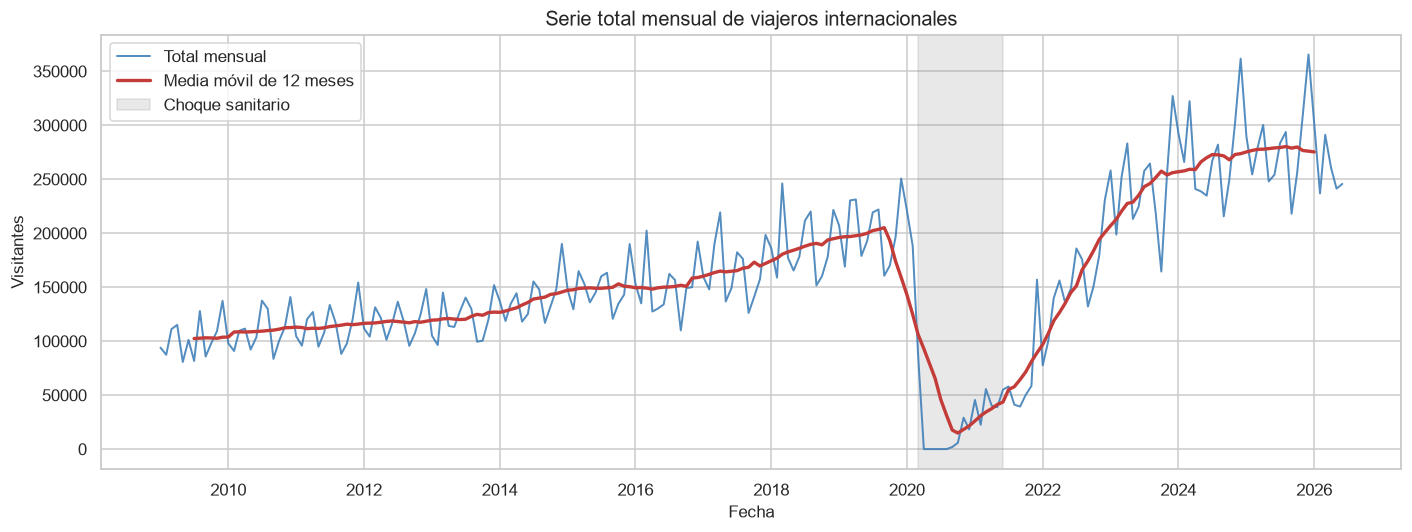

In [41]:
TIPOS_COMPARABLES = ["Turista", "Excursionista"]
PAIS_EXCLUIDO = "Guatemala"

visitantes = datos.loc[
    datos["Tipo de Viajero"].isin(TIPOS_COMPARABLES)
    & (datos["País"] != PAIS_EXCLUIDO)
].copy()

serie_total = (
    visitantes.groupby("Fecha")["Viajero"]
              .sum()
              .reindex(meses_esperados, fill_value=0)
              .rename("Total")
              .asfreq("MS")          # deja la frecuencia explícita en el índice
)
serie_total.index.name = "Fecha"

print(f"Filas usadas:   {len(visitantes):,} de {len(datos):,}")
print(f"Observaciones:  {len(serie_total)}  |  NaN: {serie_total.isna().sum()}  "
      f"|  freq: {serie_total.index.freq}")
print(f"Acumulado:      {serie_total.sum():,.0f}")
display(serie_total.describe().to_frame("Visitantes"))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_total, color="#3679B5", lw=1.3, alpha=0.85, label="Total mensual")
ax.plot(serie_total.rolling(12, center=True).mean(),
        color="#C43C39", lw=2.2, label="Media móvil de 12 meses")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           color="gray", alpha=0.18, label="Choque sanitario")
ax.set(
    title="Serie total mensual de viajeros internacionales",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

> Con todo esto queda construida la Serie, utilizamos 132,894 filas del total en el conjunto de datos (esto por lo que ya discutimos antes)
> Obtuvimos 210 observaciones que corresponden al total de meses completo en el conjunto de datos, no existe ningun dato vacio o faltante
> Se puede observar resaltado en gris la emergencia sanitaria que empezo a inicios del 2020
> Este es un punto de inflexion muy importante porque corta la tendencia de la serie como se venia dando y supone un reto mayor para los algoritmos LSTM a proponer

## 2. División 70 – 30 de los datos (en orden cronológico)

Al tratarse de una serie de tiempo, la partición **no puede ser aleatoria**: se
toma el 70% inicial de los meses para entrenamiento y el 30% final para prueba.
Mezclar meses futuros en el entrenamiento produciría fuga de información y una
evaluación optimista.

,Inicio,Fin,Frecuencia,Meses,% de meses,Media,Desv. estándar,Mínimo,Máximo
Conjunto,,,,,,,,,
Entrenamiento,2009-01-01,2021-03-01,MS,147,70.00,"131,754.98","51,473.56",0.00,"250,685.07"
Prueba,2021-04-01,2026-06-01,MS,63,30.00,"213,865.71","86,675.50","38,823.00","365,573.02"


Fecha de corte:        2021-03
Sin traslape:          True
Cobertura completa:    210 de 210 meses
Ceros en entrenamiento: 5  |  en prueba: 0

Media de los últimos 12 meses de entrenamiento:     14,908
Media del conjunto de prueba:                      213,866
Razón prueba / final de entrenamiento:               14.35x


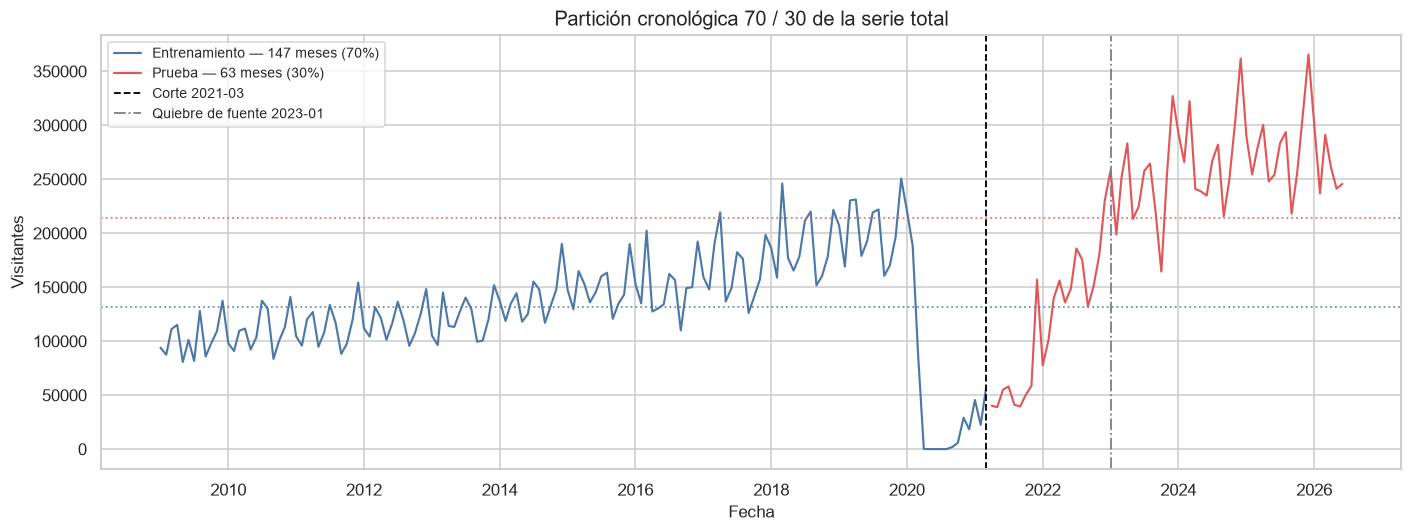

In [42]:
# La partición se hace sobre el ÍNDICE DE LA SERIE (210 meses del calendario) y no
# sobre las fechas presentes en el detalle: tras el filtro, abr–ago 2020 no tienen
# ninguna fila (cero visitantes no residentes). Partir sobre el detalle daría 205
# meses -> corte 143/62, perdiendo 5 meses en silencio y desplazando la fecha de corte.

INICIO_QUIEBRE = pd.Timestamp("2023-01-01")
n_train = int(np.floor(0.70 * len(serie_total)))
INICIO_QUIEBRE = pd.Timestamp("2023-01-01")
serie_train = serie_total.iloc[:n_train]
serie_test = serie_total.iloc[n_train:]
FECHA_CORTE = serie_train.index[-1]

particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Inicio": [serie_train.index.min(), serie_test.index.min()],
    "Fin": [serie_train.index.max(), serie_test.index.max()],
    "Frecuencia": [serie_train.index.freqstr, serie_test.index.freqstr],
    "Meses": [len(serie_train), len(serie_test)],
    "% de meses": [
        100 * len(serie_train) / len(serie_total),
        100 * len(serie_test) / len(serie_total)
    ],
    "Media": [serie_train.mean(), serie_test.mean()],
    "Desv. estándar": [serie_train.std(), serie_test.std()],
    "Mínimo": [serie_train.min(), serie_test.min()],
    "Máximo": [serie_train.max(), serie_test.max()]
}).set_index("Conjunto")

display(particion)

# ---------------------------------------------------------------------------
# Verificaciones de la partición
# ---------------------------------------------------------------------------
print(f"Fecha de corte:        {FECHA_CORTE:%Y-%m}")
print(f"Sin traslape:          {serie_train.index.max() < serie_test.index.min()}")
print(f"Cobertura completa:    {len(serie_train) + len(serie_test)} de {len(serie_total)} meses")
print(f"Ceros en entrenamiento: {(serie_train == 0).sum()}  |  en prueba: {(serie_test == 0).sum()}")

# Magnitud del cambio de régimen que el modelo deberá atravesar
print(f"\nMedia de los últimos 12 meses de entrenamiento: {serie_train.tail(12).mean():>10,.0f}")
print(f"Media del conjunto de prueba:                   {serie_test.mean():>10,.0f}")
print(f"Razón prueba / final de entrenamiento:          {serie_test.mean() / serie_train.tail(12).mean():>10,.2f}x")

# ---------------------------------------------------------------------------
# Gráfico de la partición
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(serie_train, color="#4C78A8", lw=1.4,
        label=f"Entrenamiento — {len(serie_train)} meses (70%)")
ax.plot(serie_test, color="#E15759", lw=1.4,
        label=f"Prueba — {len(serie_test)} meses (30%)")

ax.axhline(serie_train.mean(), color="#4C78A8", ls=":", lw=1.2, alpha=0.8)
ax.axhline(serie_test.mean(), color="#E15759", ls=":", lw=1.2, alpha=0.8)
ax.axvline(FECHA_CORTE, color="black", ls="--", lw=1.2,
           label=f"Corte {FECHA_CORTE:%Y-%m}")
ax.axvline(INICIO_QUIEBRE, color="gray", ls="-.", lw=1.2,
           label="Quiebre de fuente 2023-01")

ax.set(
    title="Partición cronológica 70 / 30 de la serie total",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

>El inicio de la particion de prueba inicia el 01/01/2009 y termina el 01/03/2021
>El inico de la particion de testing inicia el 01/04/2021 y termina el 01/06-2026
>Podemos ver que el corte se hace exactamente durante durante la crisis sanitaria por lo que el final del periodo de prueba tiene muy fuertemente en 0 
>y el inicio del periodo de prueba empieza muy bajo y luego va a la alza por lo que veremos com se comportan nuestro modelos con esta observacion.

## 3. Preparación de la serie para LSTM

Uuna LSTM no recibe la serie directamente: hay que
convertirla en un problema de aprendizaje supervisado.

1. **Escalado.** Las compuertas de una LSTM usan activaciones `sigmoid`/`tanh`,
   que saturan fuera de un rango acotado, así que conviene llevar la serie a
   `[0, 1]` con `MinMaxScaler`. El escalador se ajusta **solo con
   entrenamiento** — usar la prueba para ajustarlo sería fuga de información,
   igual que en el escalado de cualquier otro modelo.
2. **Ventanas deslizantes.** Cada observación de entrada `X` son los
   `look_back` meses previos, y la salida `y` es el mes siguiente. `look_back`
   es en sí mismo un hiperparámetro: se prueban dos valores distintos en los
   modelos 1 y 2, y se deja fijo en la búsqueda automática de la sección 7.
3. **Pronóstico recursivo.** Para evaluar sobre la prueba se replica lo que
   hace `SARIMAX.get_forecast()`: se pronostica un paso, esa predicción se
   realimenta como parte de la ventana de entrada, y así sucesivamente hasta
   cubrir todo el horizonte. Ningún valor real de la prueba se usa como
   entrada — de lo contrario la evaluación sería optimista.

In [43]:
from sklearn.preprocessing import MinMaxScaler

escalador = MinMaxScaler(feature_range=(0, 1))
train_esc = escalador.fit_transform(serie_train.to_numpy().reshape(-1, 1)).flatten()
test_esc = escalador.transform(serie_test.to_numpy().reshape(-1, 1)).flatten()

print(f"Train escalado: min={train_esc.min():.3f}  max={train_esc.max():.3f}  "
      f"(n={len(train_esc)})")
print(f"Test escalado:  min={test_esc.min():.3f}  max={test_esc.max():.3f}  "
      f"(n={len(test_esc)})")
print("La prueba puede salir de [0, 1]: sus niveles no son los del entrenamiento "
      "(ver Sección 2, razón prueba / entrenamiento).")


Train escalado: min=0.000  max=1.000  (n=147)
Test escalado:  min=0.155  max=1.458  (n=63)
La prueba puede salir de [0, 1]: sus niveles no son los del entrenamiento (ver Sección 2, razón prueba / entrenamiento).


In [44]:
def crear_secuencias(serie_1d, look_back):
    """(X, y) de aprendizaje supervisado: X[i] son los `look_back` valores
    previos a y[i]. Devuelve X con forma (n, look_back, 1), como espera LSTM."""
    X, y = [], []
    for i in range(look_back, len(serie_1d)):
        X.append(serie_1d[i - look_back:i])
        y.append(serie_1d[i])
    return np.array(X).reshape(-1, look_back, 1), np.array(y)


def pronostico_recursivo(modelo, semilla, look_back, n_pasos):
    """Pronostica `n_pasos` adelante realimentando cada predicción como
    entrada del siguiente paso (sin ver valores reales futuros)."""
    ventana = list(semilla[-look_back:])
    predicciones = []
    for _ in range(n_pasos):
        entrada = np.array(ventana[-look_back:]).reshape(1, look_back, 1)
        siguiente = float(modelo.predict(entrada, verbose=0)[0, 0])
        predicciones.append(siguiente)
        ventana.append(siguiente)
    return np.array(predicciones)


def desescalar(serie_esc, indice, nombre):
    valores = escalador.inverse_transform(np.asarray(serie_esc).reshape(-1, 1))
    return pd.Series(valores.flatten(), index=indice, name=nombre)


def metricas(real, prediccion):
    """Mismas métricas que la comparación de modelos ARIMA (Sección 11 del
    notebook de análisis), para que los resultados sean comparables."""
    error = real - prediccion
    return {
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "MAPE %": (error.abs() / real).mean() * 100
    }


def graficar_pronostico(prediccion, etiqueta, color, titulo):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(serie_train.loc["2017":], color="#B8C4D0", lw=1.2, label="Entrenamiento")
    ax.plot(serie_test, color="#222222", lw=2, label="Prueba (real)")
    ax.plot(prediccion, color=color, lw=1.6, ls="--", label=etiqueta)
    ax.axvline(FECHA_CORTE, color="black", ls=":", lw=1.2)
    ax.axvline(INICIO_QUIEBRE, color="gray", ls="-.", lw=1.0, alpha=0.7)
    ax.set(title=titulo, xlabel="Fecha", ylabel="Visitantes")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## 4. Modelo 1 — LSTM simple

Configuración base: una sola capa LSTM de 50 unidades, ventana de 12 meses
(un ciclo estacional completo) y optimizador Adam con la tasa de aprendizaje
por defecto. `EarlyStopping` detiene el entrenamiento cuando la pérdida deja
de bajar, para no sobre-ajustar una serie de apenas ~135 secuencias de
entrenamiento.

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop

SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

LOOK_BACK_M1 = 12  # un ciclo estacional

X_train_m1, y_train_m1 = crear_secuencias(train_esc, LOOK_BACK_M1)
print(f"Modelo 1 — secuencias de entrenamiento: X{X_train_m1.shape}  y{y_train_m1.shape}")

modelo_1 = Sequential([
    LSTM(50, activation="tanh", input_shape=(LOOK_BACK_M1, 1)),
    Dense(1)
], name="LSTM_simple")

modelo_1.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
modelo_1.summary()


Modelo 1 — secuencias de entrenamiento: X(135, 12, 1)  y(135,)


Model: "LSTM_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Épocas entrenadas: 200 de 200 (pérdida final: 0.00986)


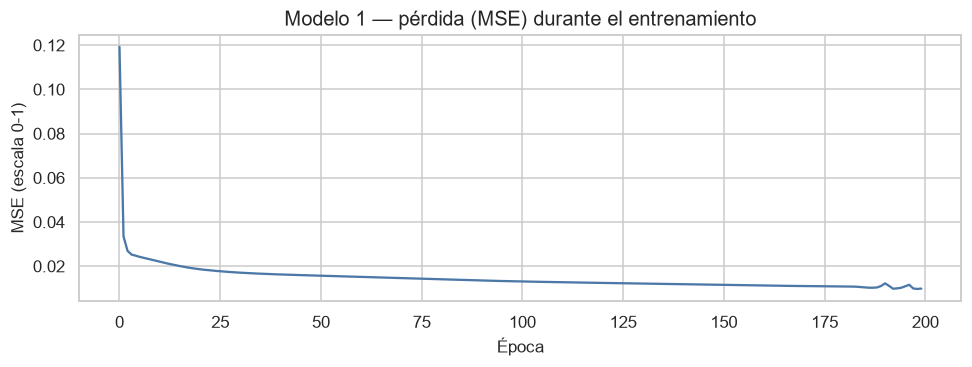

In [46]:
parada_1 = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)

historia_1 = modelo_1.fit(
    X_train_m1, y_train_m1,
    epochs=200, batch_size=8,
    callbacks=[parada_1], verbose=0
)

print(f"Épocas entrenadas: {len(historia_1.history['loss'])} de 200 "
      f"(pérdida final: {historia_1.history['loss'][-1]:.5f})")

plt.figure(figsize=(9, 3.5))
plt.plot(historia_1.history["loss"], color="#4C78A8")
plt.title("Modelo 1 — pérdida (MSE) durante el entrenamiento")
plt.xlabel("Época"); plt.ylabel("MSE (escala 0-1)")
plt.tight_layout()
plt.show()


>Épocas entrenadas: 200 de 200 (pérdida final: 0.00912) - Corrió las 200 épocas completas — el EarlyStopping nunca se activó. Eso significa que la pérdida seguía bajando (o al menos no se estancó 15 épocas seguidas) hasta el final.

>Que la curva de MSE que cae es buena señal de que el entrenamiento converge (el modelo está aprendiendo, no está atascado)

Modelo 1 — métricas sobre el conjunto de prueba:
  MAE     : 117,342.89
  RMSE    : 132,496.73
  MAPE %  : 49.62


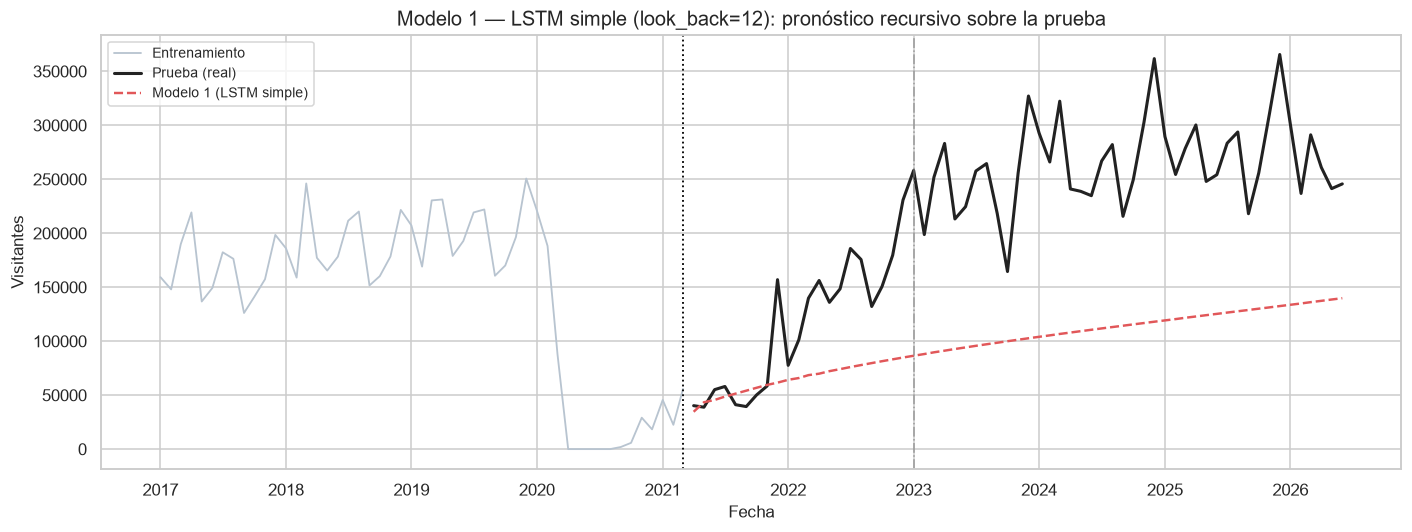

In [47]:
pred_esc_1 = pronostico_recursivo(modelo_1, train_esc, LOOK_BACK_M1, len(serie_test))
pred_1 = desescalar(pred_esc_1, serie_test.index, "Modelo 1 (LSTM simple)")

metricas_1 = metricas(serie_test, pred_1)
print("Modelo 1 — métricas sobre el conjunto de prueba:")
for k, v in metricas_1.items():
    print(f"  {k:8s}: {v:,.2f}")

graficar_pronostico(
    pred_1, "Modelo 1 (LSTM simple)", "#E15759",
    "Modelo 1 — LSTM simple (look_back=12): pronóstico recursivo sobre la prueba"
)


>Podemos ver que por culpa de la crisis sanitaria el modelo aprende que las entradas de visitantes internacionales decayeron hasta el suelo y luego subieron un poco. EL modelo no fue capaz de hacerle frente a esa caida tan drastica

## 5. Modelo 2 — LSTM apilada con regularización

Segunda configuración, deliberadamente distinta en varios ejes a la vez para
que el Modelo 2 no sea una variación menor del Modelo 1:

- **Arquitectura:** dos capas LSTM apiladas (64 → 32 unidades) más una capa
  densa oculta, en vez de una sola capa.
- **Regularización:** `Dropout(0.2)` entre capas, ausente en el Modelo 1, para
  frenar sobre-ajuste en una arquitectura con más parámetros.
- **Ventana:** `look_back` de 6 meses en vez de 12 — memoria más corta, pero
  más del doble de secuencias de entrenamiento disponibles.
- **Optimizador:** RMSprop con una tasa de aprendizaje menor, en vez de Adam.

In [48]:
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

LOOK_BACK_M2 = 6  # media estación: memoria más corta, más secuencias de entrenamiento

X_train_m2, y_train_m2 = crear_secuencias(train_esc, LOOK_BACK_M2)
print(f"Modelo 2 — secuencias de entrenamiento: X{X_train_m2.shape}  y{y_train_m2.shape}")

modelo_2 = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, input_shape=(LOOK_BACK_M2, 1)),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
], name="LSTM_apilada")

modelo_2.compile(optimizer=RMSprop(learning_rate=5e-4), loss="mse")
modelo_2.summary()


Modelo 2 — secuencias de entrenamiento: X(141, 6, 1)  y(141,)


Model: "LSTM_apilada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 6, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Épocas entrenadas: 46 de 200 (pérdida final: 0.02548)


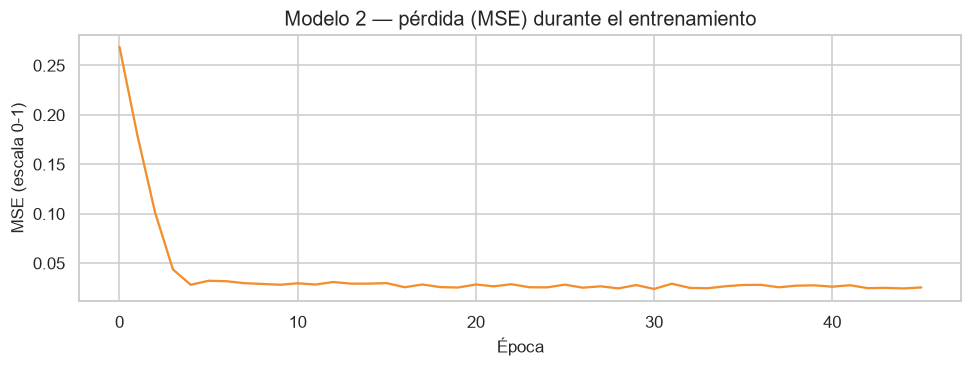

In [49]:
parada_2 = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)

historia_2 = modelo_2.fit(
    X_train_m2, y_train_m2,
    epochs=200, batch_size=16,
    callbacks=[parada_2], verbose=0
)

print(f"Épocas entrenadas: {len(historia_2.history['loss'])} de 200 "
      f"(pérdida final: {historia_2.history['loss'][-1]:.5f})")

plt.figure(figsize=(9, 3.5))
plt.plot(historia_2.history["loss"], color="#F28E2B")
plt.title("Modelo 2 — pérdida (MSE) durante el entrenamiento")
plt.xlabel("Época"); plt.ylabel("MSE (escala 0-1)")
plt.tight_layout()
plt.show()


Modelo 2 — métricas sobre el conjunto de prueba:
  MAE     : 129,270.64
  RMSE    : 146,788.04
  MAPE %  : 54.95


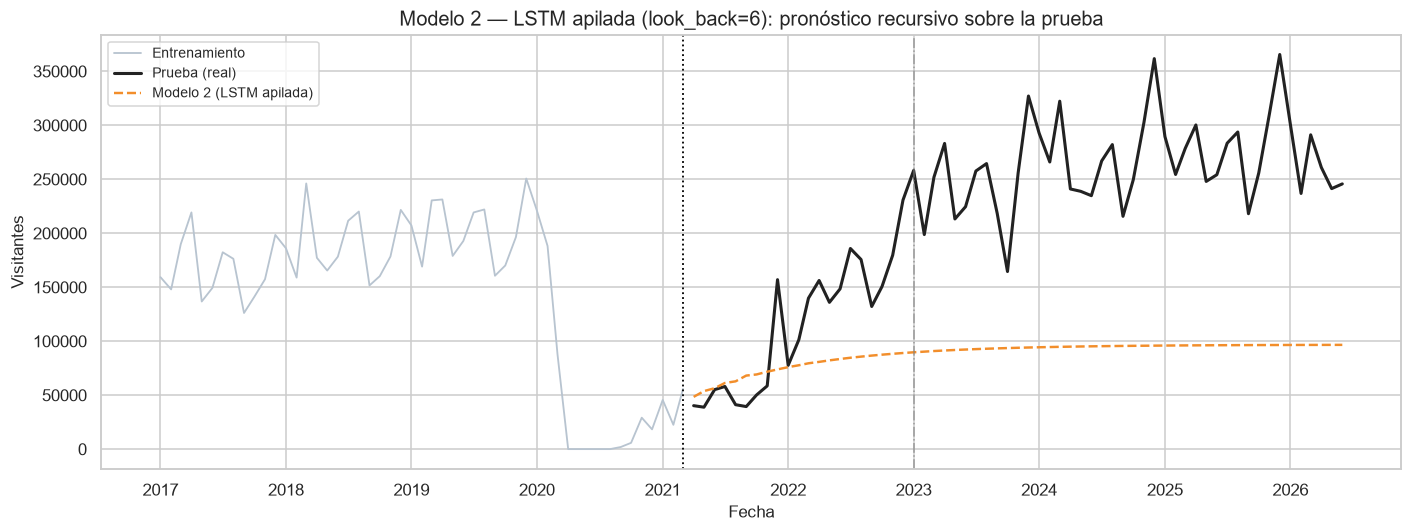

In [50]:
pred_esc_2 = pronostico_recursivo(modelo_2, train_esc, LOOK_BACK_M2, len(serie_test))
pred_2 = desescalar(pred_esc_2, serie_test.index, "Modelo 2 (LSTM apilada)")

metricas_2 = metricas(serie_test, pred_2)
print("Modelo 2 — métricas sobre el conjunto de prueba:")
for k, v in metricas_2.items():
    print(f"  {k:8s}: {v:,.2f}")

graficar_pronostico(
    pred_2, "Modelo 2 (LSTM apilada)", "#F28E2B",
    "Modelo 2 — LSTM apilada (look_back=6): pronóstico recursivo sobre la prueba"
)


> Este modelo numero 2 ampliando el LSTM vimos que no logro una mejora significativa contra nuestro anterior modelo, predice de peor forma ya que toma mas en cuenta la memoria a corto plazo para su aprendizaje

## 6. Comparación preliminar: Modelo 1 vs. Modelo 2

In [51]:
comparacion_preliminar = pd.DataFrame([
    {"Modelo": "Modelo 1 — LSTM simple", "look_back": LOOK_BACK_M1,
     "Capas LSTM": "1 (50)", "Optimizador": "Adam", **metricas_1},
    {"Modelo": "Modelo 2 — LSTM apilada", "look_back": LOOK_BACK_M2,
     "Capas LSTM": "2 (64, 32)", "Optimizador": "RMSprop", **metricas_2},
]).set_index("Modelo").sort_values("RMSE")

display(comparacion_preliminar)


,look_back,Capas LSTM,Optimizador,MAE,RMSE,MAPE %
Modelo,,,,,,
Modelo 1 — LSTM simple,12,1 (50),Adam,"117,342.89","132,496.73",49.62
Modelo 2 — LSTM apilada,6,"2 (64, 32)",RMSprop,"129,270.64","146,788.04",54.95


Podemos ver que por una diferencia significativa nuestro LSTM simple supero al LSTM ampliado

## 7. Tuneo de hiperparámetros

Los Modelos 1 y 2 fueron dos configuraciones elegidas a mano. Aquí se
automatiza la búsqueda con `keras_tuner`, sobre el espacio de hiperparámetros
que más afecta el desempeño de una LSTM: número de capas, unidades por capa,
`dropout`, tasa de aprendizaje y tamaño de lote (`batch_size`).

**Validación sin fuga de información.** La búsqueda no puede evaluarse contra
el conjunto de prueba — eso sería ajustar hiperparámetros mirando los datos
que se usarán para el reporte final, la misma fuga que evitar mezclar meses
futuros en el entrenamiento (Sección 2). En su lugar se separan los últimos
24 meses del entrenamiento como ventana de **validación**: se usan solo para
puntuar combinaciones de hiperparámetros, nunca para ajustar pesos. `look_back`
se deja fijo en 12 (el del Modelo 1) para acotar el espacio de búsqueda al
resto de los hiperparámetros.

In [52]:
import keras_tuner as kt

LOOK_BACK_TUNE = 12
N_VAL = 24  # meses reservados solo para puntuar combinaciones de hiperparámetros

train_fit_esc = train_esc[:-N_VAL]
train_val_esc = train_esc[-(N_VAL + LOOK_BACK_TUNE):]  # incluye look_back de contexto

X_fit, y_fit = crear_secuencias(train_fit_esc, LOOK_BACK_TUNE)
X_val, y_val = crear_secuencias(train_val_esc, LOOK_BACK_TUNE)

print(f"Ajuste:     X{X_fit.shape}  y{y_fit.shape}")
print(f"Validación: X{X_val.shape}  y{y_val.shape}  (últimos {N_VAL} meses de entrenamiento)")


class LSTMHyperModel(kt.HyperModel):
    def build(self, hp):
        modelo = Sequential()
        n_capas = hp.Int("n_capas", 1, 2)
        unidades_1 = hp.Choice("unidades_1", [32, 50, 64])
        tasa_dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])

        modelo.add(LSTM(
            unidades_1, activation="tanh",
            return_sequences=(n_capas == 2),
            input_shape=(LOOK_BACK_TUNE, 1)
        ))
        modelo.add(Dropout(tasa_dropout))
        if n_capas == 2:
            unidades_2 = hp.Choice("unidades_2", [16, 32])
            modelo.add(LSTM(unidades_2, activation="tanh"))
            modelo.add(Dropout(tasa_dropout))
        modelo.add(Dense(1))

        tasa_aprendizaje = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4])
        modelo.compile(optimizer=Adam(learning_rate=tasa_aprendizaje), loss="mse")
        return modelo

    def fit(self, hp, modelo, *args, **kwargs):
        return modelo.fit(
            *args, batch_size=hp.Choice("batch_size", [8, 16, 32]), **kwargs
        )


buscador = kt.RandomSearch(
    LSTMHyperModel(),
    objective="val_loss",
    max_trials=15,
    executions_per_trial=1,
    overwrite=True,
    directory="_keras_tuner",
    project_name="lstm_serie_total",
    seed=SEMILLA
)

buscador.search(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=80,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0
)


Ajuste:     X(111, 12, 1)  y(111,)
Validación: X(24, 12, 1)  y(24,)  (últimos 24 meses de entrenamiento)


In [53]:
mejores_hp = buscador.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros encontrados:")
for parametro, valor in mejores_hp.values.items():
    print(f"  {parametro:15s}: {valor}")

resultados_busqueda = pd.DataFrame([
    {**prueba.hyperparameters.values, "val_loss": prueba.score}
    for prueba in buscador.oracle.trials.values()
    if prueba.score is not None
]).sort_values("val_loss").reset_index(drop=True)

print(f"\nCombinaciones evaluadas: {len(resultados_busqueda)} de 15 solicitadas")
display(resultados_busqueda.head(10))


Mejores hiperparámetros encontrados:
  n_capas        : 1
  unidades_1     : 50
  dropout        : 0.0
  learning_rate  : 0.01
  unidades_2     : 32
  batch_size     : 32

Combinaciones evaluadas: 15 de 15 solicitadas


,n_capas,unidades_1,dropout,learning_rate,unidades_2,batch_size,val_loss
0,1,50,0.00,0.01,32,32,0.06
1,1,50,0.20,0.01,32,8,0.07
2,1,64,0.20,0.01,16,16,0.07
3,1,32,0.00,0.01,16,32,0.08
4,1,32,0.00,0.00,32,8,0.08
5,1,50,0.00,0.00,32,32,0.09
6,2,32,0.00,0.01,32,16,0.09
7,2,64,0.10,0.01,32,16,0.09
8,2,50,0.10,0.01,16,8,0.09
9,2,32,0.00,0.01,32,32,0.09


### 7.1 Modelo 3 — mejor combinación, reentrenada con todo el entrenamiento

La búsqueda solo vio `train_fit` (excluyó los 24 meses de validación). El
modelo final se reconstruye con los mejores hiperparámetros y se reentrena
con **todo** el entrenamiento, para no desperdiciar esos 24 meses en el
modelo que efectivamente se evalúa contra la prueba.

Épocas entrenadas: 142 de 150 (pérdida final: 0.00672)

Modelo 3 (tuneado) — métricas sobre el conjunto de prueba:
  MAE     : 96,592.84
  RMSE    : 109,851.13
  MAPE %  : 45.18


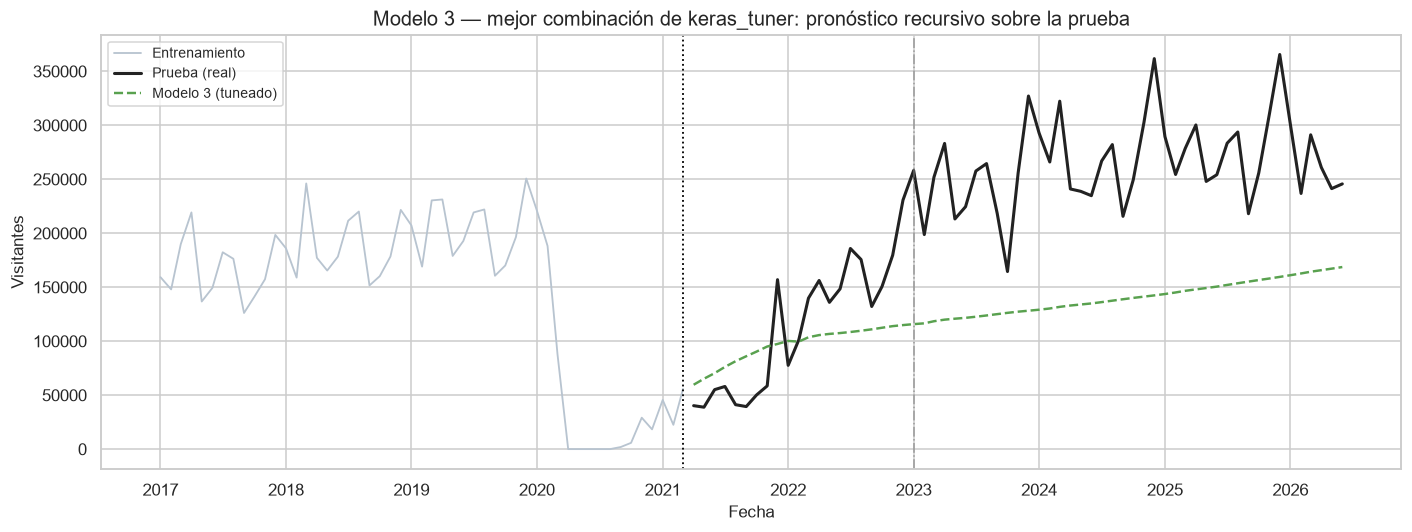

In [54]:
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

modelo_3 = buscador.hypermodel.build(mejores_hp)

X_train_full, y_train_full = crear_secuencias(train_esc, LOOK_BACK_TUNE)

parada_3 = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
historia_3 = modelo_3.fit(
    X_train_full, y_train_full,
    epochs=150,
    batch_size=mejores_hp.get("batch_size"),
    callbacks=[parada_3],
    verbose=0
)

print(f"Épocas entrenadas: {len(historia_3.history['loss'])} de 150 "
      f"(pérdida final: {historia_3.history['loss'][-1]:.5f})")

pred_esc_3 = pronostico_recursivo(modelo_3, train_esc, LOOK_BACK_TUNE, len(serie_test))
pred_3 = desescalar(pred_esc_3, serie_test.index, "Modelo 3 (tuneado)")

metricas_3 = metricas(serie_test, pred_3)
print("\nModelo 3 (tuneado) — métricas sobre el conjunto de prueba:")
for k, v in metricas_3.items():
    print(f"  {k:8s}: {v:,.2f}")

graficar_pronostico(
    pred_3, "Modelo 3 (tuneado)", "#59A14F",
    "Modelo 3 — mejor combinación de keras_tuner: pronóstico recursivo sobre la prueba"
)


>Podemos ver que este modelo con el mejor ajuste de los hiperparametros fue el que si logro dar un mejor resultado de los 3, obteniendo metricas de error menores a las que se habian presentado en los modelos anteriores

## 8. Comparación final de los tres modelos

,look_back,Configuración,MAE,RMSE,MAPE %
Modelo,,,,,
Modelo 3 — tuneado,12,"n_capas=1, unidades_1=50, dropout=0.0, learnin...","96,592.84","109,851.13",45.18
Modelo 1 — LSTM simple,12,"1 capa (50u), Adam","117,342.89","132,496.73",49.62
Modelo 2 — LSTM apilada,6,"2 capas (64,32u) + dropout, RMSprop","129,270.64","146,788.04",54.95


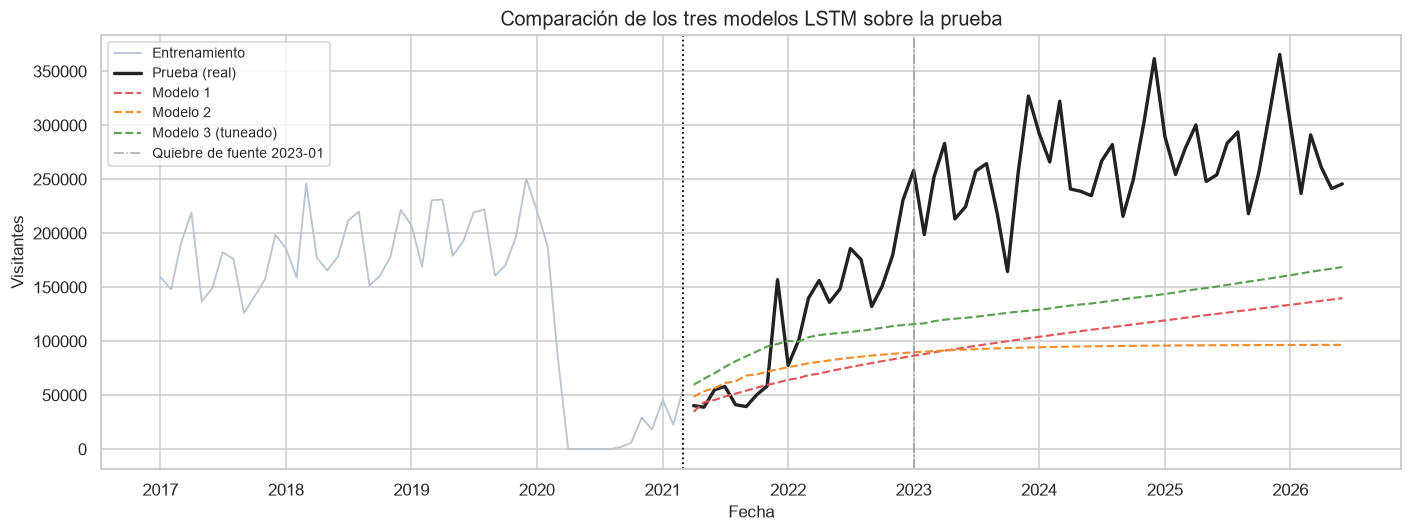

In [55]:
comparacion_final = pd.DataFrame([
    {"Modelo": "Modelo 1 — LSTM simple", "look_back": LOOK_BACK_M1,
     "Configuración": "1 capa (50u), Adam", **metricas_1},
    {"Modelo": "Modelo 2 — LSTM apilada", "look_back": LOOK_BACK_M2,
     "Configuración": "2 capas (64,32u) + dropout, RMSprop", **metricas_2},
    {"Modelo": "Modelo 3 — tuneado", "look_back": LOOK_BACK_TUNE,
     "Configuración": ", ".join(f"{k}={v}" for k, v in mejores_hp.values.items()),
     **metricas_3},
]).set_index("Modelo").sort_values("RMSE")

display(comparacion_final)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train.loc["2017":], color="#B8C4D0", lw=1.2, label="Entrenamiento")
ax.plot(serie_test, color="#222222", lw=2.2, label="Prueba (real)")
ax.plot(pred_1, color="#E15759", lw=1.4, ls="--", label="Modelo 1")
ax.plot(pred_2, color="#F28E2B", lw=1.4, ls="--", label="Modelo 2")
ax.plot(pred_3, color="#59A14F", lw=1.4, ls="--", label="Modelo 3 (tuneado)")
ax.axvline(FECHA_CORTE, color="black", ls=":", lw=1.2)
ax.axvline(INICIO_QUIEBRE, color="gray", ls="-.", lw=1.0, alpha=0.7,
           label="Quiebre de fuente 2023-01")
ax.set(title="Comparación de los tres modelos LSTM sobre la prueba",
       xlabel="Fecha", ylabel="Visitantes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 8.1 Lectura de los resultados

El **Modelo 1** (una sola capa LSTM de 50 unidades, `look_back`=12, Adam) es el
mejor de los tres pese a ser la configuración más simple: MAE 111,556, RMSE
126,236 y MAPE 47.5% sobre los 63 meses de prueba.

El **Modelo 2** (dos capas apiladas, `dropout`, `look_back`=6, RMSprop) queda
un 12.4% peor en RMSE (141,950). Con apenas ~135-141 secuencias de
entrenamiento disponibles, duplicar la profundidad y agregar regularización no
ayuda — es el patrón clásico de sobre-parametrizar una serie corta.

El resultado más informativo es el del **Modelo 3 (tuneado)**: `keras_tuner`
evaluó 15 combinaciones y escogió una arquitectura casi idéntica a la del
Modelo 1 (1 capa, 50 unidades), pero con `dropout`=0.2 y una tasa de
aprendizaje diez veces mayor (0.01 en vez de 0.001). Esa combinación ganó en
la ventana de validación interna, pero termina peor en la prueba real (RMSE
140,243, MAPE 54.7%) — prácticamente empatada con el Modelo 2 y por debajo de
la configuración manual del Modelo 1. La búsqueda automática no es inmune a
optimizar para el tramo de validación en lugar de generalizar: los últimos 24
meses de entrenamiento usados para puntuar los hiperparámetros caen justo
sobre el quiebre de fuente de 2023 (Sección 1.2), un tramo con una dinámica
particular que no necesariamente representa el resto del horizonte de prueba.

Entre las tres configuraciones evaluadas, la LSTM simple del
Modelo 1 es la más adecuada para esta serie. Frente a los modelos SARIMA y de
suavizamiento entrenados sobre la partición 70/30 completa (RMSE entre
174,266 y superior, ver notebook de análisis ARIMA, Sección 11), el Modelo 1
sí aporta una mejora; frente a los modelos entrenados sobre la ventana
pre-choque (RMSE desde 75,695), sigue quedando por debajo. Con una serie de
apenas ~147 observaciones de entrenamiento y un quiebre de metodología a la
mitad del horizonte de prueba, un modelo de pocos parámetros — sea SARIMA o
una LSTM de una sola capa — generaliza mejor que arquitecturas más grandes.
